<a href="https://colab.research.google.com/github/scelliot-cpu/Elliott_DSPN_26/blob/master/ExerciseSubmissions/09_classifiers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 9: Classification

This homework assignment is designed to give you practice with classification models. We'll try to predict which words are more likely to be responded to correctly during a lexical decision task, based on their length and frequency.

We will be using data from the English Lexicon Project again. However, this time we will use response correctness as our dependent variable. Load **LexicalData_withIncorrect.csv**, which includes incorrect trials as well as correct ones, and also **Items.csv**. Both can be found in the *Homework/lexDat* folder in the class GitHub repository.

This data is a subset of the [English Lexicon Project database](https://elexicon.wustl.edu/). It provides response correctness and reaction times (in milliseconds) of many subjects as they are presented with letter strings and asked to decide, as quickly and as accurately as possible, whether the letter string is a word or not. The **Items.csv** provides characteristics of the words used, namely frequency (how common is this word?) and length (how many letters?).

*Data courtesy of Balota, D.A., Yap, M.J., Cortese, M.J., Hutchison, K.A., Kessler, B., Loftis, B., Neely, J.H., Nelson, D.L., Simpson, G.B., & Treiman, R. (2007). The English Lexicon Project. Behavior Research Methods, 39, 445-459.*

---
## 1. Loading and formatting the data (2 point)

Load in data from the **LexicalData_withIncorrect.csv** and **Items.csv** files. Use `left_join` to add word characteristics `Length` and `Log_Freq_Hal` from **Items** to the **LexicalData**, and use `drop_na()` to get rid of any observations with missing values. Then use `head()` to look at the first few rows of the data.

*Note: We're just working with `Correct` in this homework, so no need to worry about reformatting reaction times.*

In [1]:
install.packages("tidyverse")
library(tidyverse)

setwd("/content/")
lexical_dat <- read.csv("LexicalData_withIncorrect.csv")
items_dat <- read.csv("Items.csv")

lexical_dat_clean <- lexical_dat %>%
left_join(items_dat %>% select(Word, Length, Log_Freq_HAL), by = c("D_Word"="Word")) %>%
drop_na()

head(lexical_dat_clean)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


,X,Sub_ID,Trial,Type,D_RT,D_Word,Outlier,D_Zscore,Correct,Length,Log_Freq_HAL
,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>
1,1,157,1,1,710,browse,false,-0.437,1,6,8.856
2,2,67,1,1,"1,094",refrigerant,false,0.825,1,11,4.644
3,3,120,1,1,587,gaining,false,-0.645,1,7,8.304
4,4,21,1,1,984,cheerless,false,0.025,1,9,2.639
5,5,236,1,1,577,pattered,false,-0.763,1,8,1.386
6,6,236,2,1,715,conjures,false,-0.364,1,8,5.268


---
## 2. Visualizing the data (1 point)

First, we'll try to visualize whether trials that are responded to correctly versus incorrectly differ from each other in terms of word length and log frequency. The code is included below, so that this homework doesn't get too cumbersome. All you have to do is **change the name of the data set**, **run the code**, and **write some observations about the output**.

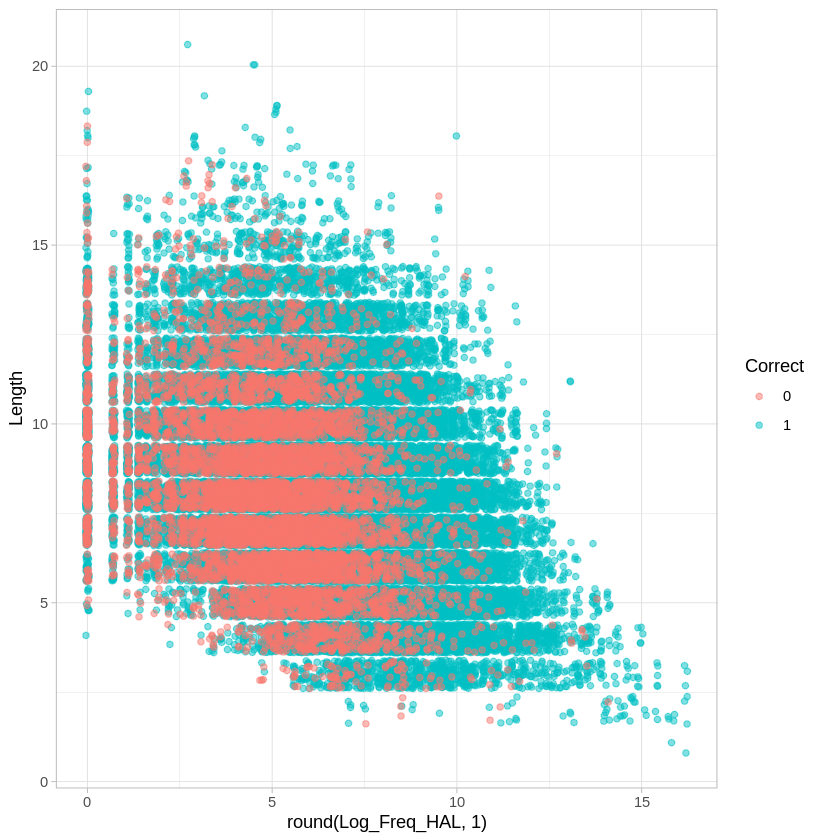

In [2]:

lexical_dat_clean$Correct <- as.factor(lexical_dat_clean$Correct) # so that R knows that Correct is categorical, not numeric.

# plot the Correct / Incorrect clusters
ggplot(lexical_dat_clean,aes(x=round(Log_Freq_HAL,1),y=Length,col=Correct)) + geom_point(position="jitter",alpha=0.5) + theme_light()


What do you observe about the "Correct" and "Incorrect" clusters?

The clusters are pretty similar, with a not much of a pattern in responses. It does look like there is somewhat of a negative correlation between length and log frequency for both correct and incorrect responses. In general, incorrect responses seem to have a less strong negative correlation and have lower log frequencies.

---
## 3. Logistic Regression: Fitting the model (3 points)

Fit a logistic regression model to the data using `Length`, `Log_Freq_HAL`, and their interaction to predict `Correct`. Use `glm()` to fit the model, and look at its output using `summary()`.

In [3]:
lex_glm <- glm(Correct ~ Length * Log_Freq_HAL, data = lexical_dat_clean, family = binomial)
summary(lex_glm)


Call:
glm(formula = Correct ~ Length * Log_Freq_HAL, family = binomial, 
    data = lexical_dat_clean)

Coefficients:
                     Estimate Std. Error z value Pr(>|z|)    
(Intercept)         -0.939996   0.115623  -8.130 4.30e-16 ***
Length               0.151266   0.012789  11.828  < 2e-16 ***
Log_Freq_HAL         0.394772   0.018762  21.041  < 2e-16 ***
Length:Log_Freq_HAL -0.010558   0.002202  -4.795 1.63e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 49809  on 70588  degrees of freedom
Residual deviance: 46563  on 70585  degrees of freedom
AIC: 46571

Number of Fisher Scoring iterations: 5


What can you conclude from this output? (a brief gist is fine)

>

* Length singificantly predicts the amount of correct responses, this is a positive correlation (0.151), we know this because the p-value is < 2e-16
* Log frequency also significantly predicts the amount of responses, this is a stronger positive correlation (0.395), we know this because the p-value is < 2e-16
* The interaction between length and log frequency is also significant, with the p-value of 1.63e-06, this is a negative correlaiton



---
## 4. Interpreting predictions from the model (4 points)

Finally, look at how well this logistic regression model does at predicting correctness. Use `predict()` and a threshold of 0.5 to generate predicted `Correct` values for each trial, then output a confusion matrix and overall accuracy for these predictions.

*Hint: see the Classifiers tutorial.*

In [6]:
glm_prob = data.frame(predict(lex_glm, type = "response"))
colnames(glm_prob) = c('predicted_prob')

num_observations = nrow(glm_prob)
glm_prob$index = seq(1, num_observations)

threshold = 0.5

glm_prob$predicted_binary=rep(0,num_observations)

glm_prob$predicted_binary[glm_prob$predicted_prob>threshold]= 1

confusion_df = data.frame(glm_prob$predicted_binary, lexical_dat_clean$Correct)
colnames(confusion_df) = c('predicted', 'actual')

table(confusion_df)
print(paste("Accuracy:",mean(confusion_df$predicted == confusion_df$actual)))

         actual
predicted     0     1
        0    13    44
        1  7966 62566

[1] "Accuracy: 0.886526229299183"


Did the model do well at predicting lexical decision correctness? Why or why not?

> The model did pretty good at predicting lexical decision correctness, with an overall accuracy of 88.65%. It correctly predicted 13 incorrect responses and 62566 correct responses, however, had 44 false incorrect predictions and 7966 false correct predictions. This mean that the model predicted a lot of the incorrect responses as correct, with only 13 of them being correctly identified as incorrect. So why it was overall good at predicting lexical decision correctness, it was much better at predicting correcting responses than incorrect responses.

**DUE:** 11:59pm EST, March 3, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*

**GenAI Utilization** Did you utilize any generative AI tools on this assignment? If so, please list the item and the paste respective prompt you used.
>